In [1]:
import pandas as pd
import MySQLdb
acm = pd.read_csv('D:\\Projects\\Python NBs and Files\\MINI PROJECT_1\\IMDB_Action_Movies.csv')
anm = pd.read_csv('D:\\Projects\\Python NBs and Files\\MINI PROJECT_1\\IMDB_Animation_Movies.csv')
rom = pd.read_csv('D:\\Projects\\Python NBs and Files\\MINI PROJECT_1\\IMDB_Romance_Movies.csv')
fan = pd.read_csv('D:\\Projects\\Python NBs and Files\\MINI PROJECT_1\\IMDB_Fantasy_Movies.csv')

thr = pd.read_csv('D:\\Projects\\Python NBs and Files\\MINI PROJECT_1\\IMDB_Thriller_Movies.csv')


df = pd.concat([acm, anm, rom, fan, thr], ignore_index=True)
df


,Title,Rating,Votes,Duration,Genre
0,1. Gladiator II,6.5,(253K),2h 28m,Action
1,2. Dune: Part Two,8.5,(643K),2h 46m,Action
2,3. Twisters,6.5,(176K),2h 2m,Action
3,4. Kraven the Hunter,5.5,(63K),2h 7m,Action
4,5. The Ministry of Ungentlemanly Warfare,6.8,(139K),2h 2m,Action
...,...,...,...,...,...
3639,2093. Blues de la Civilización,5.2,(7),1h 9m,Thriller
3640,2117. Spider-Man: Dimension Rift,8.4,(14),2h 7m,Thriller
3641,2159. The Hunt for August Red,6.6,(23),1h 47m,Thriller
3642,2160. Gadha17,8.0,(12),1h 30m,Thriller


In [2]:
df.to_csv('D:\\Projects\\Python NBs and Files\\MINI PROJECT_1\\IMDB_Raw_Movies.csv', index=False)

In [2]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3644 entries, 0 to 3643
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Title     3644 non-null   object 
 1   Rating    3644 non-null   float64
 2   Votes     3644 non-null   object 
 3   Duration  3644 non-null   object 
 4   Genre     3644 non-null   object 
dtypes: float64(1), object(4)
memory usage: 142.5+ KB


In [3]:
df['Votes'] = df['Votes'].str.replace(')', '')
df['Votes'] = df['Votes'].str.replace('(', '')
df['Votes'] = df['Votes'].str.replace('K', '000')
df['Votes'] = df['Votes'].str.replace('.', '')
df['Votes'] = df['Votes'].astype(int)


In [4]:
df

,Title,Rating,Votes,Duration,Genre
0,1. Gladiator II,6.5,253000,2h 28m,Action
1,2. Dune: Part Two,8.5,643000,2h 46m,Action
2,3. Twisters,6.5,176000,2h 2m,Action
3,4. Kraven the Hunter,5.5,63000,2h 7m,Action
4,5. The Ministry of Ungentlemanly Warfare,6.8,139000,2h 2m,Action
...,...,...,...,...,...
3639,2093. Blues de la Civilización,5.2,7,1h 9m,Thriller
3640,2117. Spider-Man: Dimension Rift,8.4,14,2h 7m,Thriller
3641,2159. The Hunt for August Red,6.6,23,1h 47m,Thriller
3642,2160. Gadha17,8.0,12,1h 30m,Thriller


C:\Users\admin\AppData\Local\Temp\ipykernel_20452\3229969305.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxenplot(x='Rating', y='Genre', data=df, palette='Set2')


Text(0, 0.5, 'Genre')

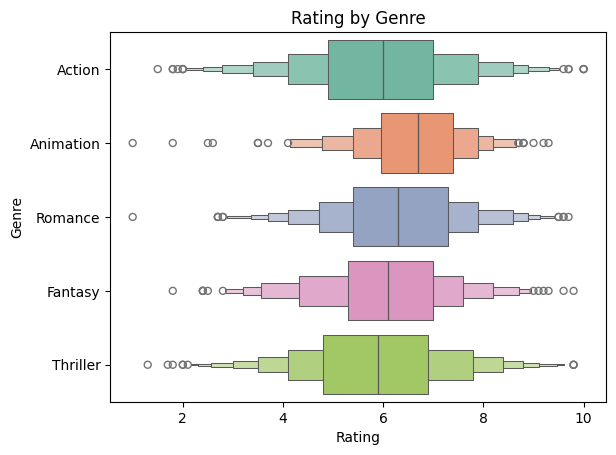

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns  

sns.boxenplot(x='Rating', y='Genre', data=df, palette='Set2')
plt.title('Rating by Genre')
plt.xlabel('Rating')
plt.ylabel('Genre')


C:\Users\admin\AppData\Local\Temp\ipykernel_20452\3347453416.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxenplot(x='Votes', y='Genre', data=df, palette='Set2')


Text(0, 0.5, 'Genre')

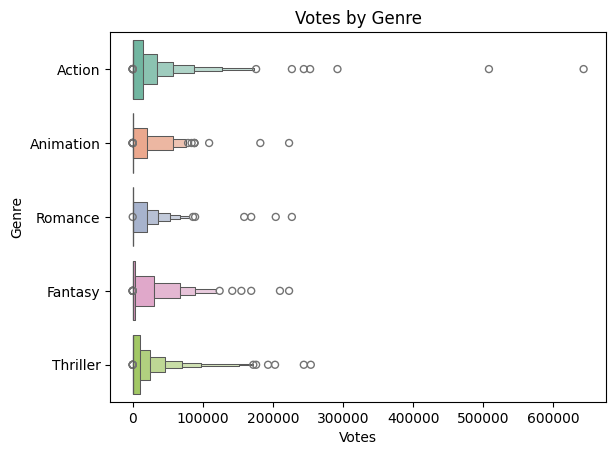

In [6]:
sns.boxenplot(x='Votes', y='Genre', data=df, palette='Set2')
plt.title('Votes by Genre')
plt.xlabel('Votes')
plt.ylabel('Genre')


In [7]:
# Example: Remove outliers in 'Votes' using IQR
Q1 = df['Votes'].quantile(0.25)
Q3 = df['Votes'].quantile(0.75)
IQR = Q3 - Q1
cdf = df[(df['Votes'] >= Q1 - 1.5 * IQR) & (df['Votes'] <= Q3 + 1.5 * IQR)]


In [8]:
# Example: Remove outliers in 'Rating' using IQR
Q1 = cdf['Rating'].quantile(0.25)
Q3 = cdf['Rating'].quantile(0.75)
IQR = Q3 - Q1
cdf = cdf[(cdf['Rating'] >= Q1 - 1.5 * IQR) & (cdf['Rating'] <= Q3 + 1.5 * IQR)]

C:\Users\admin\AppData\Local\Temp\ipykernel_20452\4176890714.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxenplot(x='Votes', y='Genre', data=cdf, palette='Set2')


<Axes: xlabel='Votes', ylabel='Genre'>

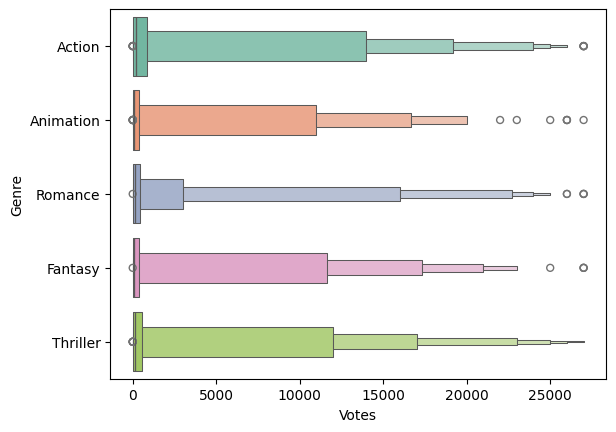

In [9]:
sns.boxenplot(x='Votes', y='Genre', data=cdf, palette='Set2')

C:\Users\admin\AppData\Local\Temp\ipykernel_20452\1955314971.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Rating', y='Genre', data=cdf, palette='Set2')


<Axes: xlabel='Rating', ylabel='Genre'>

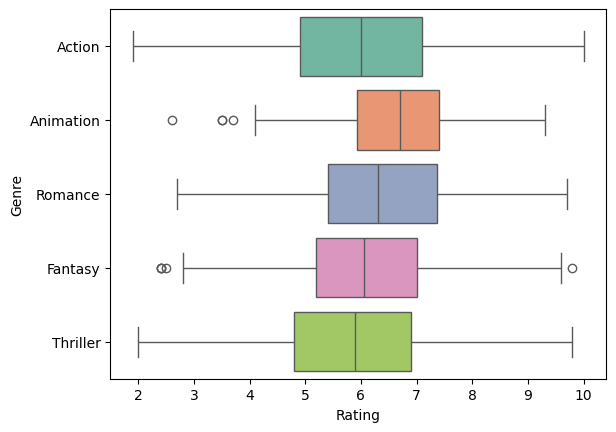

In [10]:
sns.boxplot(x='Rating', y='Genre', data=cdf, palette='Set2')

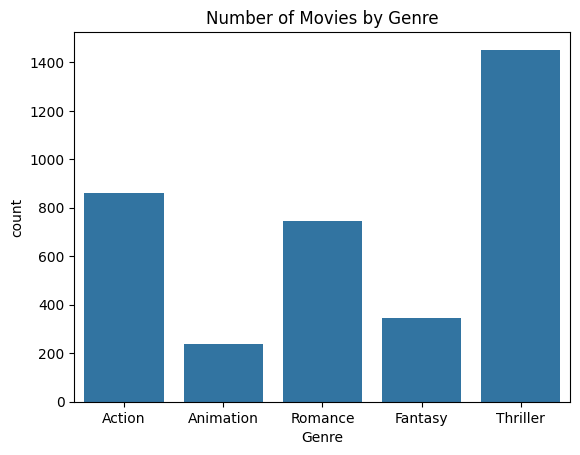

In [11]:
sns.countplot(x='Genre', data=df)
plt.title('Number of Movies by Genre')
plt.show()

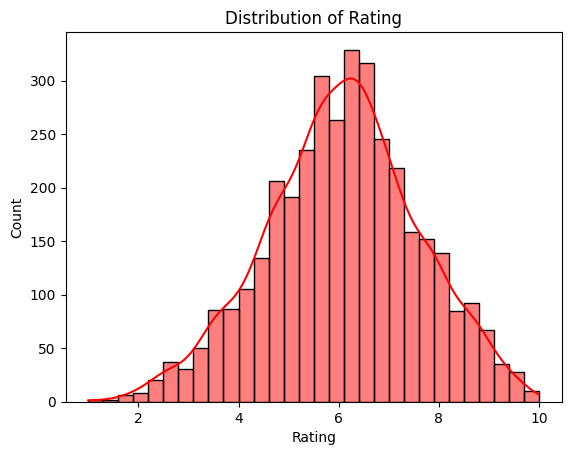

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.histplot(df['Rating'], bins=30, kde=True, color='red')
plt.title('Distribution of Rating')

plt.show()

In [13]:
cdf

,Title,Rating,Votes,Duration,Genre
6,7. The Unholy Trinity,6.1,522,1h 35m,Action
12,13. Fight or Flight,6.4,14000,1h 42m,Action
23,24. Absolution,5.2,9000,1h 52m,Action
31,32. Drive-Away Dolls,5.4,24000,1h 24m,Action
32,33. 40 Acres,6.8,381,1h 53m,Action
...,...,...,...,...,...
3639,2093. Blues de la Civilización,5.2,7,1h 9m,Thriller
3640,2117. Spider-Man: Dimension Rift,8.4,14,2h 7m,Thriller
3641,2159. The Hunt for August Red,6.6,23,1h 47m,Thriller
3642,2160. Gadha17,8.0,12,1h 30m,Thriller


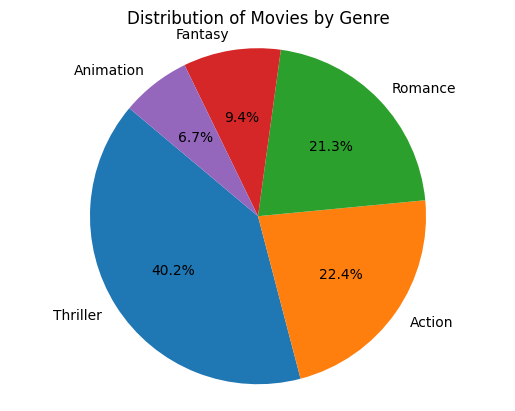

In [15]:
plt.pie(cdf['Genre'].value_counts(), labels=cdf['Genre'].value_counts().index, autopct='%1.1f%%', startangle=140)
plt.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle.
plt.title('Distribution of Movies by Genre')
plt.show()

In [14]:
cdf.to_csv('D:\\Projects\\Python NBs and Files\\MINI PROJECT_1\\IMDB_Cleaned_Movies.csv', index=False)

In [ ]:
import pandas as pd
import psycopg2
from io import StringIO



# Convert DataFrame to CSV in memory
csv_buffer = StringIO()
df.to_csv(csv_buffer, index=False, header=True)
csv_buffer.seek(0)

# Connection details
conn = psycopg2.connect(
    dbname="IMDb_Mini_Project",
    user="",
    password="your_password",
    host="localhost",
    port="5432"
)

cur = conn.cursor()

# Create table if not exists (example schema)
cur.execute("""
    CREATE TABLE IF NOT EXISTS my_table (
        id INT,
        name TEXT,
        age INT
    )
""")

# Copy data from CSV buffer into PostgreSQL
cur.copy_expert("COPY my_table FROM STDIN WITH CSV HEADER", csv_buffer)

conn.commit()
cur.close()
conn.close()

print("DataFrame successfully copied to PostgreSQL via CSV!")
